# 1 import heart disease dataset

In [1]:
import pandas as pd

df = pd.read_csv("heart.csv")

print("First 10 Rows:")
print(df.head(10))

print("\nShape:")
print(df.shape)

print("\nDataset Information:")
df.info()

First 10 Rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up        

# 2 check for missing values

In [2]:
import pandas as pd

df = pd.read_csv("heart.csv")

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


# 3 check and remove duplicate rows

In [3]:
import pandas as pd

df = pd.read_csv("heart.csv")

print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape:")
print(df.shape)

Duplicate Rows: 0
New Shape:
(918, 12)


# 4 identify invalid values

In [4]:
import pandas as pd

df = pd.read_csv("heart.csv")

chol_zero = (df["Cholesterol"] == 0).sum()
bp_zero = (df["RestingBP"] == 0).sum()

print("Rows with Cholesterol = 0:", chol_zero)
print("Rows with RestingBP = 0:", bp_zero)

Rows with Cholesterol = 0: 172
Rows with RestingBP = 0: 1


# 5 clean invalid values

In [5]:
import pandas as pd

df = pd.read_csv("heart.csv")

print("Before Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

# Mean excluding zeros
chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

# Replace zeros with mean
df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

# Round values
df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("\nAfter Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

Before Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


# 6 plot holigrams 2x2 layout

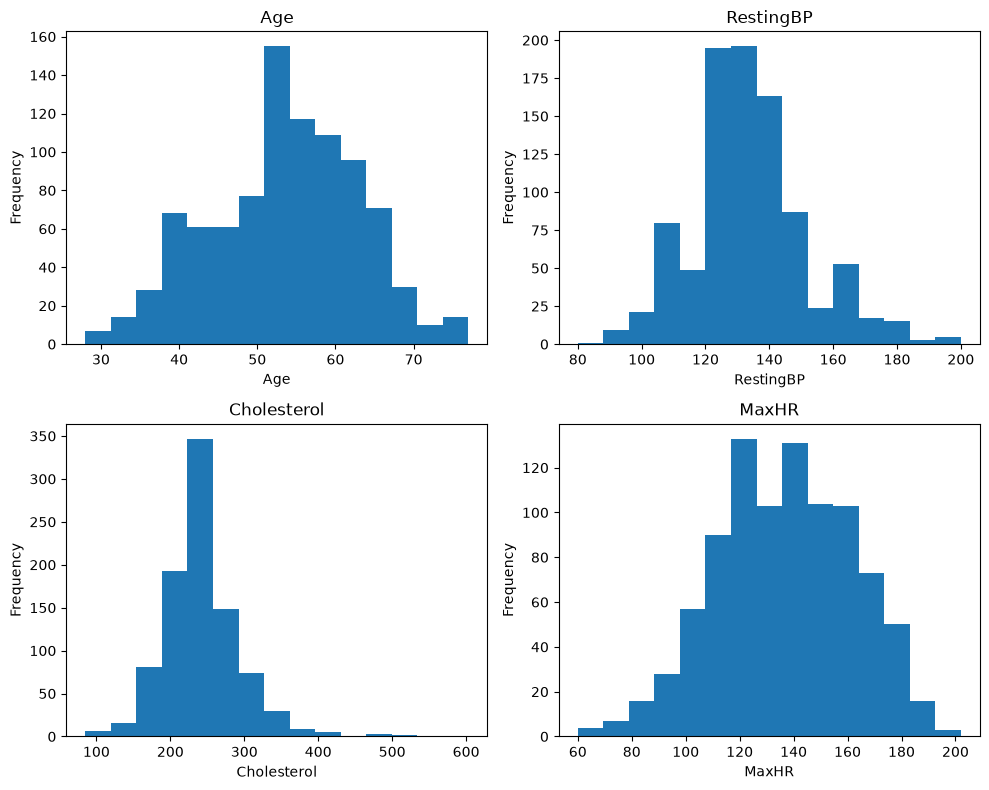

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("heart.csv")

# Cleaning
chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

# Function
def plot_histogram(column, position):
    plt.subplot(2, 2, position)
    plt.hist(df[column], bins=15)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.figure(figsize=(10, 8))

plot_histogram("Age", 1)
plot_histogram("RestingBP", 2)
plot_histogram("Cholesterol", 3)
plot_histogram("MaxHR", 4)

plt.tight_layout()
plt.show()

# 7 Identify Numerical and Categorical Columns

In [7]:
import pandas as pd

df = pd.read_csv("heart.csv")

numerical = df.select_dtypes(include="number").columns
categorical = df.select_dtypes(exclude="number").columns

print("Numerical Columns:")
print(numerical)

print("\nCategorical Columns:")
print(categorical)

Numerical Columns:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='str')

Categorical Columns:
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')


# 8 performing one hot encoding

In [8]:
import pandas as pd

df = pd.read_csv("heart.csv")

# Cleaning invalid values
chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

# One-Hot Encoding
df_encoded = pd.get_dummies(df)

print("Shape of Encoded Dataset:")
print(df_encoded.shape)

print("\nFirst 5 Rows:")
print(df_encoded.head())

Shape of Encoded Dataset:
(918, 21)

First 5 Rows:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH

# 9 final shapes and columns names

In [9]:
import pandas as pd

df = pd.read_csv("heart.csv")

# Cleaning
chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

# Encoding
df_encoded = pd.get_dummies(df)

print("Final Shape:")
print(df_encoded.shape)

print("\nColumn Names:")
print(df_encoded.columns)

Final Shape:
(918, 21)

Column Names:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')


# SUMMARY

1. Invalid values were found in the Cholesterol and RestingBP columns where some rows contained 0. These values were replaced with the mean of the respective column after excluding zero values.

2. Handling invalid values is important because a cholesterol value or resting blood pressure of 0 is not medically realistic. Such values can reduce the accuracy of analysis and machine learning models.

3. One-Hot Encoding converts categorical columns into numerical columns so that machine learning algorithms can process the data correctly.

4. After cleaning and encoding, the dataset became more suitable for data analysis and machine learning by removing unrealistic values and converting categorical features into numeric form.